# Stimulus creation and psycholinguistic characterisation

This notebook builds the final stimulus set for the MEG/EEG specificity experiment and documents its psycholinguistic properties.

**Pipeline:**
1. Assemble the trial-level stimulus dataframe from the hand-curated specificity triads
2. Look up psycholinguistic properties for each target noun from published norm databases
3. Reduce the item set from 120 to 100 triads to fit within the MEG recording budget
4. Retrieve bigram frequencies for the mid-specificity adjective–noun phrases from Google Books Ngrams
5. Summarise and visualise psycholinguistic properties by specificity condition
6. Export the final stimulus list

In [1]:
import random
from datetime import date

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import time
from scipy import stats

## 1. Assemble the stimulus dataframe

The input file `specificity_material.xlsx` contains one row per conceptual triad (n=120), with columns for:
- `word_lowSpec`: the general noun (e.g. *bird*)
- `phrase_word1`: the adjective used in the mid-specificity phrase (e.g. *nocturnal*)
- `phrase_word2`: the noun in the phrase, identical to `word_lowSpec` (e.g. *bird*)
- `word_highSpec`: the specific noun (e.g. *owl*)

The output is a long-format dataframe with three rows per triad (one per specificity level). Each trial has two stimulus slots:
- `word1`: the first stimulus shown — a consonant string (low/high) or the adjective (mid)
- `word2`: the second stimulus shown — always the critical noun

Consonant strings are randomly sampled (seed=42) from a fixed pool to serve as non-semantic visual placeholders, matched approximately for length.

In [2]:
specificity_material = pd.read_excel('specificity_material.xlsx')
n_sets = len(specificity_material)

# Pool of unpronounceable consonant strings used as non-semantic placeholders
# in single-word (low and high specificity) trials
consonant_pool = [
    'xkq', 'qxsw', 'mtpv', 'rjdnw', 'wvcnz', 'zbxlv', 'tqvgqrz', 'bxfjwts',
    'mghljkqr', 'kmlsdjtw', 'ptrgsbkv', 'zrtqgfplh', 'vpbyzkgrf', 'htbqzylm',
    'ypdcglkc', 'fxldmr', 'rvqf'
]

# Sample 2 * n_sets consonant strings (one per low trial, one per high trial)
random.seed(42)
consonant_strings = random.sample(consonant_pool * 44, n_sets * 2)
consonant_low  = consonant_strings[:n_sets]   # placeholders for low-specificity trials
consonant_high = consonant_strings[n_sets:]   # placeholders for high-specificity trials

# Build the long-format dataframe: 3 rows per set (low, mid, high)
stimuli = pd.DataFrame({
    'item_nr'    : range(1, n_sets * 3 + 1),
    'set_nr'     : np.repeat(range(1, n_sets + 1), 3),
    'specificity': ['low', 'mid', 'high'] * n_sets,
    # word1: consonant string for single-word trials; adjective for phrase trials
    'word1'      : np.array([consonant_low,
                              specificity_material['phrase_word1'].values,
                              consonant_high]).T.flatten(),
    # word2: the critical noun, always the second stimulus on screen
    'word2'      : np.array([specificity_material['word_lowSpec'].values,
                              specificity_material['phrase_word2'].values,
                              specificity_material['word_highSpec'].values]).T.flatten(),
})

print(f'Stimulus dataframe: {len(stimuli)} trials across {n_sets} sets')
stimuli.head(6)

Stimulus dataframe: 360 trials across 120 sets


,item_nr,set_nr,specificity,word1,word2
0,1,1,low,mghljkqr,alloy
1,2,1,mid,brown,alloy
2,3,1,high,zrtqgfplh,bronze
3,4,2,low,vpbyzkgrf,amphibian
4,5,2,mid,hopping,amphibian
5,6,2,high,zbxlv,frog


## 2. Look up psycholinguistic properties

We look up properties for each target noun (`word2`) from the following published norm databases:

| Property | Source |
|---|---|
| Zipf frequency | SUBTLEX-UK (van Heuven et al., 2014) |
| Concreteness (mean, SD) | Brysbaert et al. (2014) |
| Imageability, Valence | Scott et al. (2019) |
| Age of acquisition | Kuperman et al. (2012) |
| Lexical decision RT | British Lexicon Project (Keuleers et al., 2012) |

Properties are merged by word form. Missing values (words absent from a given norm database) are retained as NaN.

In [3]:
# Each entry: (column name in stimuli, path to norm file, column name in norm file)
NORM_RESOURCES = [
    ('zipf',        '../resources/subtlex_uk.csv',         'LogFreq(Zipf)'),
    ('CNC_M',       '../resources/brysbaert_etal_2014.csv', 'Conc_M'),
    ('CNC_SD',      '../resources/brysbaert_etal_2014.csv', 'Conc_SD'),
    ('imageability','../resources/scott_etal_2019.csv',     'IMAG'),
    ('valence',     '../resources/scott_etal_2019.csv',     'VAL'),
    ('AoA',         '../resources/kuperman_etal_2012.csv',  'Rating.Mean'),
    ('RT',          '../resources/blp-items.xls',           'rt'),
]

def merge_norm(df, col_name, filepath, source_col):
    """Left-merge a single psycholinguistic norm onto the stimulus dataframe by word form."""
    read_fn = pd.read_excel if filepath.endswith('.xls') else pd.read_csv
    norms = read_fn(filepath, index_col=0)[source_col].rename(col_name)
    return df.merge(norms, left_on='word2', right_index=True, how='left').astype({col_name: float})

# Word length in letters (computed directly, no external resource needed)
stimuli['length'] = stimuli['word2'].str.len()

for col_name, filepath, source_col in NORM_RESOURCES:
    stimuli = merge_norm(stimuli, col_name, filepath, source_col)

print(f'Missing values per column:\n{stimuli.isnull().sum()[stimuli.isnull().sum() > 0]}')
stimuli.head(6)

/var/folders/y1/y3454vgj6jlct43dtjr44mvw0000gn/T/ipykernel_81333/1660686634.py:15: DtypeWarning: Columns (11,25) have mixed types. Specify dtype option on import or set low_memory=False.
  norms = read_fn(filepath, index_col=0)[source_col].rename(col_name)


Missing values per column:
zipf             4
CNC_M           16
CNC_SD          16
imageability    85
valence         85
AoA             13
RT              69
dtype: int64


,item_nr,set_nr,specificity,word1,word2,length,zipf,CNC_M,CNC_SD,imageability,valence,AoA,RT
0,1,1,low,mghljkqr,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667
1,2,1,mid,brown,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667
2,3,1,high,zrtqgfplh,bronze,6,4.41,4.47,1.07,6.086,6.000,10.00,543.526316
3,4,2,low,vpbyzkgrf,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN
4,5,2,mid,hopping,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN
5,6,2,high,zbxlv,frog,4,4.05,5.00,0.00,6.889,5.719,4.32,533.205128


## 3. Reduce item set from 120 to 100 triads

After piloting the experiment in the scanner with a 2s inter-trial interval (sufficient for cortical activations to return to baseline), the full 120-set design would require approximately 1.5 hours (the data collection effort included items for a separate experiment) of effective recording time, which is too long given setup and inter-block rest periods.

We reduced the set to 100 triads (300 trials total; ~43 minutes effective recording time) by removing the 20 sets with the largest Age of Acquisition (AoA) difference between the high- and low-specificity nouns. AoA was chosen as the primary pruning criterion because it was the least well-matched variable across specificity levels in the full set. Pruning on this dimension therefore improves matching while reducing trial count.

In [4]:
# Compute per-set differences between high and low specificity items
# (mid shares the same noun as low, so we compare high vs. mid)
high_low = stimuli[stimuli['specificity'].isin(['mid', 'high'])].copy()

feature_differences = (
    high_low.groupby('set_nr')[['AoA', 'zipf', 'RT']]
    .apply(lambda g: g.diff().abs().iloc[1])
    .reset_index()
)

# Remove the 20 sets with the largest AoA discrepancy between high and low nouns
sets_to_remove = (
    feature_differences
    .nlargest(20, 'AoA')
    ['set_nr']
    .tolist()
)

print(f'Sets removed (n={len(sets_to_remove)}): {sets_to_remove}')

stimuli = stimuli[~stimuli['set_nr'].isin(sets_to_remove)].reset_index(drop=True)
print(f'Final stimulus count: {len(stimuli)} trials across {stimuli.set_nr.nunique()} sets')
stimuli.head(6)

Sets removed (n=20): [47, 6, 28, 30, 58, 115, 67, 101, 64, 102, 95, 41, 38, 12, 63, 42, 75, 79, 3, 15]
Final stimulus count: 300 trials across 100 sets


,item_nr,set_nr,specificity,word1,word2,length,zipf,CNC_M,CNC_SD,imageability,valence,AoA,RT
0,1,1,low,mghljkqr,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667
1,2,1,mid,brown,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667
2,3,1,high,zrtqgfplh,bronze,6,4.41,4.47,1.07,6.086,6.000,10.00,543.526316
3,4,2,low,vpbyzkgrf,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN
4,5,2,mid,hopping,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN
5,6,2,high,zbxlv,frog,4,4.05,5.00,0.00,6.889,5.719,4.32,533.205128


## 4. Retrieve bigram frequencies for mid-specificity phrases

For the mid-specificity adjective–noun phrases, we retrieve co-occurrence frequencies from the Google Books Ngram corpus (British English, 1919–2019) as an index of how predictable each phrase is.

We compute two frequency measures:
- **Sequential frequency** (`frequency_seq`): how often the adjective immediately precedes the noun in running text (e.g. *nocturnal bird*), queried as `ADJ NOUN`
- **Dependency frequency** (`frequency_dep`): how often the noun is modified by the adjective in a dependency relationship, queried as `NOUN=>ADJ`

Frequencies are averaged across the 100-year window and log-transformed (`log10`). Phrases absent from the corpus receive a frequency of 0 (NaN after log transformation).

In [5]:
# parameters for Google Books Ngram
corpus = 'eng-GB-2019' # British English
startYear, endYear = 1919, 2019 # most recent 100 years available on Google Books Ngram
smoothing = 3 # for extrapolating in case there's missing; this is default setting 
caseInsensitive = True 

start = time.time()
print(f'Calculating bigram frequency...')
frequencies_dep = [] # dependency frequency
frequencies_seq = [] # sequence frequency
frequencies_all = [frequencies_dep, frequencies_seq] # for looping
for index, row in stimuli.iterrows():
    query_w2w1 = row.word2 + '_NOUN' + '=>' + row.word1 + '_ADJ' # dependency frequency
    query_w1w2 = row.word1 + '_ADJ' + ' ' + row.word2 + '_NOUN' # sequence frequency
    queries = [query_w2w1, query_w1w2] # for looping
    for query, frequencies in zip(queries, frequencies_all):
        params = dict(content=query, year_start=startYear, year_end=endYear,
                      corpus=corpus, smoothing=smoothing,
                      case_insensitive=caseInsensitive)
        
        try:
            # Using the /json endpoint for a cleaner, structured response
            req = requests.get('https://books.google.com/ngrams/json', params=params, timeout=10)
            req.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
            
            output = req.json()
            
            # Check if timeseries data is present and non-empty
            if output and 'timeseries' in output[0] and output[0]['timeseries']:
                timeseries = output[0]['timeseries']
                average_frequency = sum(timeseries) / len(timeseries)
                frequencies.append(average_frequency)
                print(f'  [{index}] {query}: {average_frequency:.2e}')
            else: 
                frequencies.append(0)
                
        except requests.exceptions.RequestException:
            # Append 0 if any request or parsing error occurs
            frequencies.append(0)

stimuli['frequency_dep'] = frequencies_dep
stimuli['frequency_seq'] = frequencies_seq
# phrases.to_csv(os.path.join(f'phrases_bigramFreq_{date.today()}.csv'), index=False)
end = time.time()

print(f'Total time taken: {end-start} s.')
# calculate log frequencies 
stimuli['frequency_dep_log'] = np.log10(stimuli['frequency_dep'])
stimuli['frequency_seq_log'] = np.log10(stimuli['frequency_seq'])
stimuli

Calculating bigram frequency...
  [13] large_ADJ bird_NOUN: 5.17e-08
  [16] bird_NOUN=>nocturnal_ADJ: 9.04e-10
  [16] nocturnal_ADJ bird_NOUN: 5.23e-09
  [19] waddling_ADJ bird_NOUN: 1.91e-11
  [22] bird_NOUN=>small_ADJ: 1.19e-08
  [22] small_ADJ bird_NOUN: 7.78e-08
  [25] bird_NOUN=>graceful_ADJ: 2.91e-10
  [25] graceful_ADJ bird_NOUN: 3.01e-09
  [28] boat_NOUN=>small_ADJ: 1.13e-07
  [91] diplomat_NOUN=>senior_ADJ: 3.93e-11
  [91] senior_ADJ diplomat_NOUN: 5.74e-09
  [94] dog_NOUN=>tiny_ADJ: 5.66e-10
  [94] tiny_ADJ dog_NOUN: 5.70e-09
  [100] fish_NOUN=>flat_ADJ: 1.86e-09
  [100] flat_ADJ fish_NOUN: 2.12e-08
  [103] flower_NOUN=>yellow_ADJ: 1.97e-08
  [103] yellow_ADJ flower_NOUN: 4.58e-08
  [163] pouched_ADJ mammal_NOUN: 3.46e-10
  [166] mammal_NOUN=>nocturnal_ADJ: 1.17e-10
  [166] nocturnal_ADJ mammal_NOUN: 1.25e-09
  [172] mammal_NOUN=>marine_ADJ: 6.42e-08
  [172] marine_ADJ mammal_NOUN: 1.37e-07
  [175] tall_ADJ mammal_NOUN: 1.52e-11
  [238] lustrous_ADJ sphere_NOUN: 3.56e-11
  [2

/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,item_nr,set_nr,specificity,word1,word2,length,zipf,CNC_M,CNC_SD,imageability,valence,AoA,RT,frequency_dep,frequency_seq,frequency_dep_log,frequency_seq_log
0,1,1,low,mghljkqr,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667,0.0,0.0,-inf,-inf
1,2,1,mid,brown,alloy,5,3.13,4.29,0.98,NaN,NaN,14.53,583.416667,0.0,0.0,-inf,-inf
2,3,1,high,zrtqgfplh,bronze,6,4.41,4.47,1.07,6.086,6.000,10.00,543.526316,0.0,0.0,-inf,-inf
3,4,2,low,vpbyzkgrf,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN,0.0,0.0,-inf,-inf
4,5,2,mid,hopping,amphibian,9,2.78,3.77,1.38,6.030,5.412,8.33,NaN,0.0,0.0,-inf,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,356,119,mid,violent,weather,7,5.12,3.83,1.34,NaN,NaN,5.94,538.763158,0.0,0.0,-inf,-inf
296,357,119,high,mtpv,storm,5,4.46,4.70,0.67,6.429,3.543,4.94,505.600000,0.0,0.0,-inf,-inf
297,358,120,low,kmlsdjtw,wine,4,4.84,4.79,0.50,6.618,6.229,7.90,523.000000,0.0,0.0,-inf,-inf
298,359,120,mid,sparkling,wine,4,4.84,4.79,0.50,6.618,6.229,7.90,523.000000,0.0,0.0,-inf,-inf


## 5. Summarise and visualise psycholinguistic properties

We summarise mean and SD for all psycholinguistic variables by specificity condition, and run independent-samples t-tests comparing high vs. low specificity nouns to check that the two single-word conditions are well matched on surface-level properties.

Note that the mid-specificity condition shares the same nouns as the low-specificity condition (`word2` is identical), so differences between low and mid on noun-level properties reflect only sampling variation, not a systematic difference.

In [10]:
METRICS = ['CNC_M', 'imageability', 'valence', 'AoA', 'RT', 'zipf', 'length',
           'frequency_dep_log', 'frequency_seq_log']

METRIC_LABELS = {
    'CNC_M'             : 'Concreteness',
    'imageability'      : 'Imageability',
    'valence'           : 'Valence',
    'AoA'               : 'Age of acquisition (years)',
    'RT'                : 'Lexical decision latency (ms)',
    'zipf'              : 'Zipf frequency',
    'length'            : 'Word length (letters)',
    'frequency_dep_log' : 'Bigram frequency, dependency (log)',
    'frequency_seq_log' : 'Bigram frequency, sequential (log)',
}

def compute_stats(df, feature):
    """Independent-samples t-test comparing high vs. low specificity nouns on `feature`."""
    high = df.query('specificity == "high"')[feature]
    low  = df.query('specificity == "low"')[feature]
    return stats.ttest_ind(high, low, nan_policy='omit')

# --- Summary table: mean (SD) per metric per condition ---
summary = (
    stimuli
    .groupby('specificity')[METRICS]
    .agg(['mean', 'std'])
    .round(2)
)
print('--- Mean (SD) by specificity condition ---')
print(summary.T)  # transpose for readability

# --- Statistical comparison: high vs. low ---
print('\n--- High vs. Low specificity: independent t-tests ---')
for feature in METRICS:
    t = compute_stats(stimuli, feature)
    print(f'  {feature:<25} t = {t.statistic:+.3f},  p = {t.pvalue:.3f}')

--- Mean (SD) by specificity condition ---
specificity               high     low     mid
CNC_M             mean    4.71    4.65    4.65
                  std     0.35    0.41    0.41
imageability      mean    6.45    6.32    6.32
                  std     0.50    0.62    0.62
valence           mean    5.53    5.66    5.66
                  std     0.93    0.95    0.95
AoA               mean    6.50    5.59    5.59
                  std     2.14    2.10    2.10
RT                mean  572.38  548.38  548.38
                  std    50.17   39.43   39.43
zipf              mean    3.85    4.44    4.44
                  std     0.65    0.66    0.66
length            mean    6.05    5.69    5.69
                  std     1.85    1.88    1.88
frequency_dep_log mean    -inf    -inf    -inf
                  std      NaN     NaN     NaN
frequency_seq_log mean    -inf    -inf    -inf
                  std      NaN     NaN     NaN

--- High vs. Low specificity: independent t-tests ---
  CNC_M  

/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6153: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6706: RuntimeWarning: invalid value encountered in scalar subtract
  estimate = m1 - m2
/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6153: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
/Users/ryanlaw/miniconda3/envs/mne/lib/python3.12/site-packages/scipy/stats/_stats_py.py:6706: RuntimeWarning: invalid value encountered in scalar subtract
  estimate = m1 - m2


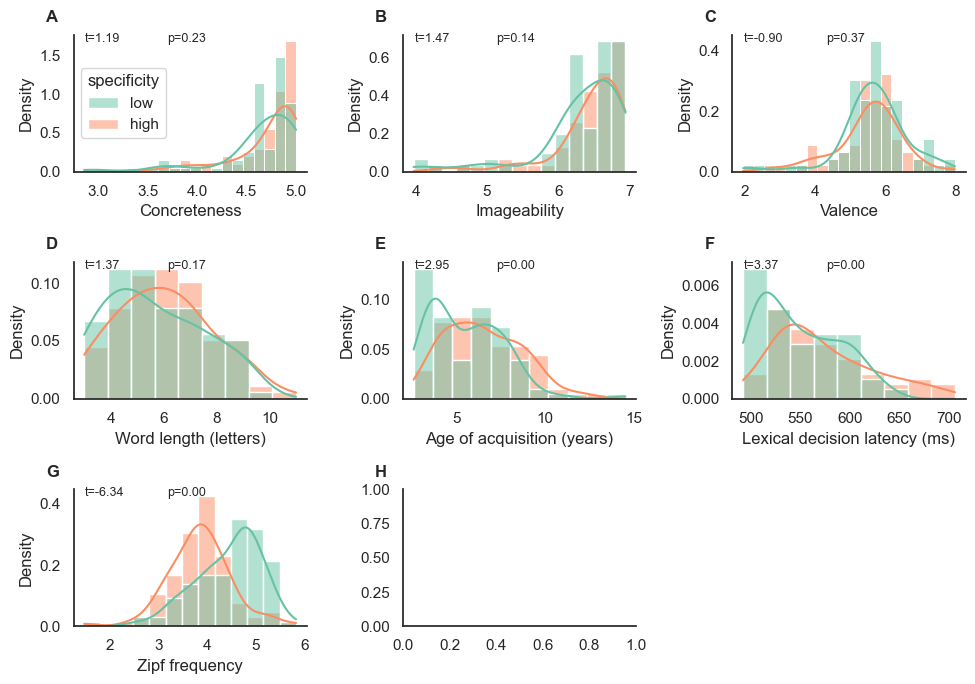

In [14]:
# --- Distribution plots: high vs. low specificity nouns ---
PLOT_METRICS = ['CNC_M', 'imageability', 'valence', 'length', 'AoA', 'RT', 'zipf']

data = stimuli.query('specificity in ["high", "low"]')

sns.set_theme(style='white', palette='Set2')
fig, axes = plt.subplots(3, 3, figsize=(10, 7))

for ax, feature in zip(axes.ravel(), PLOT_METRICS):
    sns.histplot(
        x=feature, hue='specificity', data=data,
        ax=ax, stat='density', kde=True, legend=(ax == axes[0, 0])
    )
    ax.set_xlabel(METRIC_LABELS.get(feature, feature))

    # Annotate with t-test result
    t = compute_stats(stimuli, feature)
    ax.annotate(f't={t.statistic:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=9)
    ax.annotate(f'p={t.pvalue:.2f}',   xy=(0.40, 0.95), xycoords='axes fraction', fontsize=9)

# Add panel labels (A, B, C, ...)
for ax, label in zip(axes.ravel(), 'ABCDEFGHIJ'):
    trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', va='bottom', fontweight='bold')

fig.delaxes(axes[2, 2])  # remove unused 9th panel
fig.tight_layout()
sns.despine()
plt.savefig(f'stim_properties_{date.today()}.pdf', bbox_inches='tight')
plt.show()

## 6. Export final stimulus list

In [15]:
output_fname = f'stimuli_specificity_{date.today()}.xlsx'
stimuli.to_excel(output_fname, index=False)
print(f'Saved {len(stimuli)} trials to {output_fname}')

Saved 300 trials to stimuli_specificity_2026-03-23.xlsx
